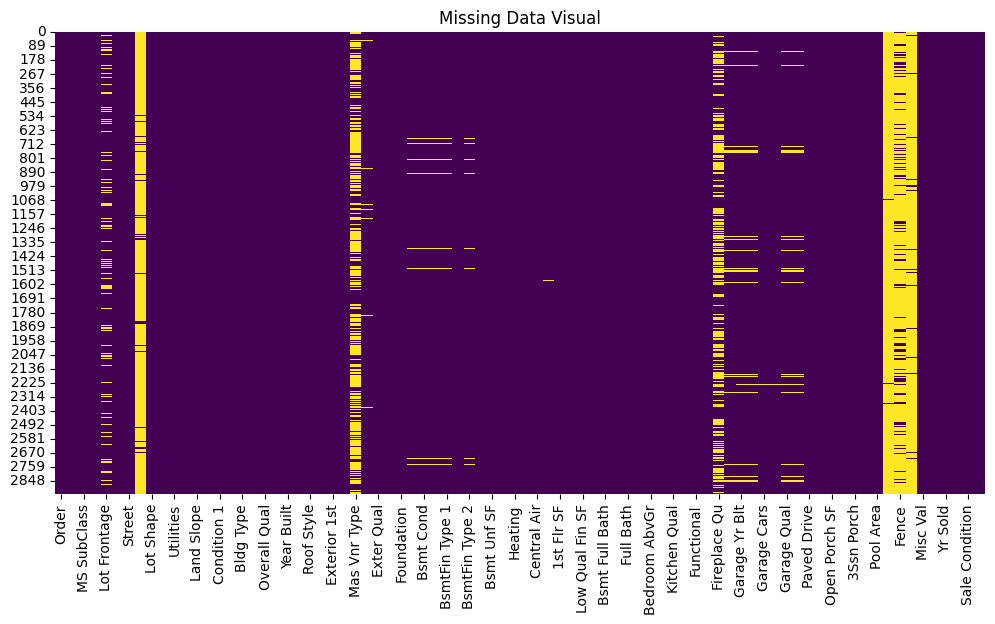

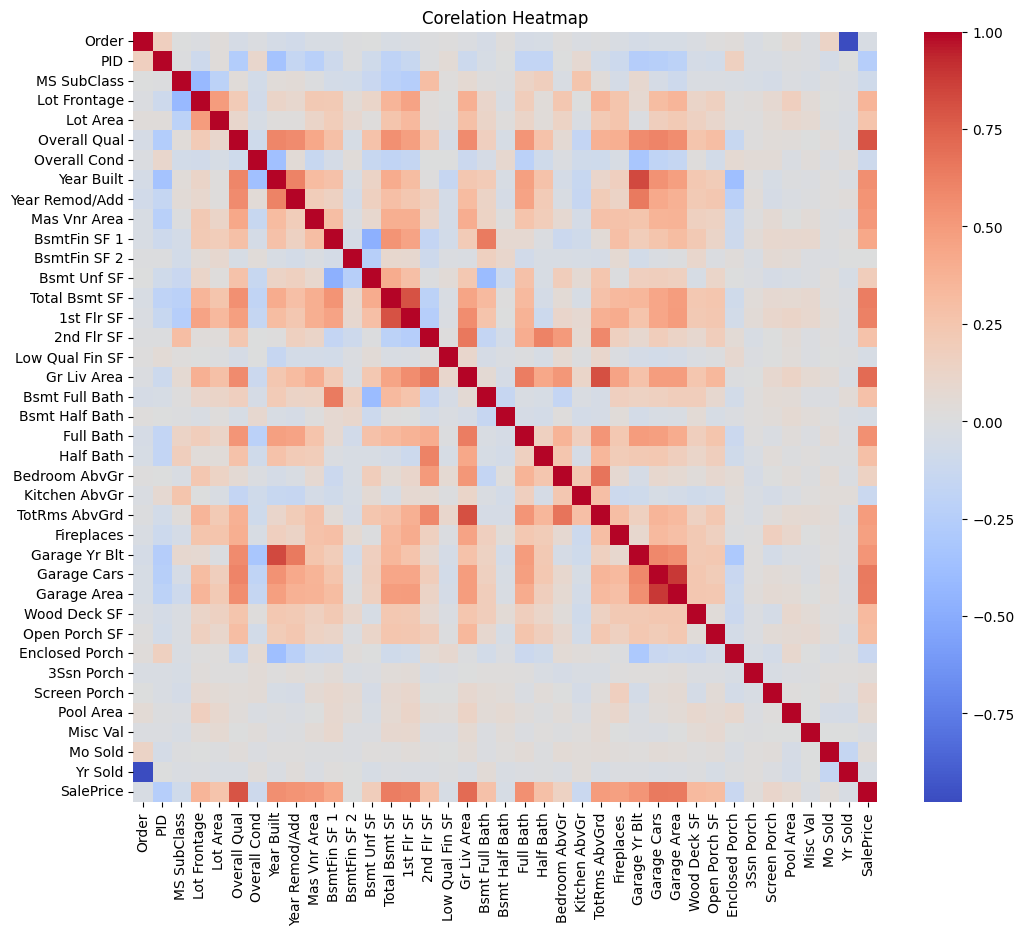

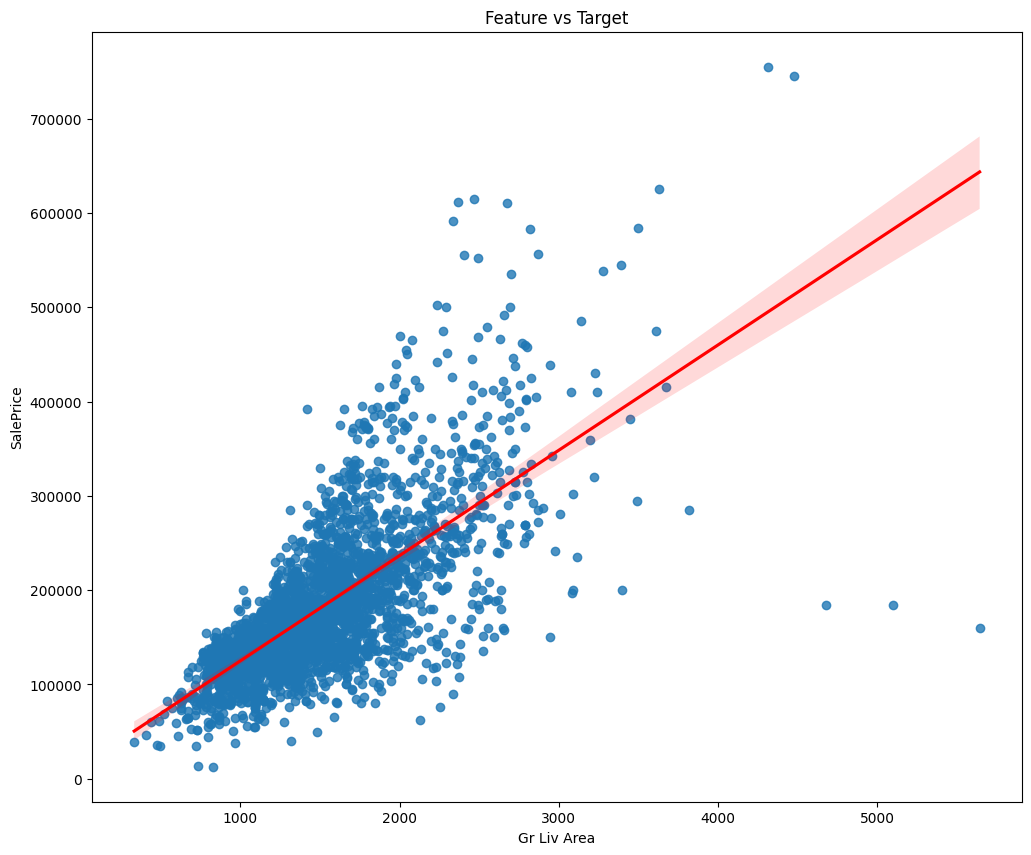

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#Reading data
df= pd.read_csv("/content/AmesHousing.csv")
df.head()

#visual 1 (Heatmap)
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(),cbar=False,cmap="viridis")
plt.title("Missing Data Visual")
plt.show()

#visual 2(Coorelation heatmap)
plt.figure(figsize=(12,10))
corr_matrix=df.corr(numeric_only=True)
sns.heatmap(corr_matrix,annot=False,cmap="coolwarm")
plt.title("Corelation Heatmap")
plt.show()

#visual 3(feature vs Target)
plt.figure(figsize=(12,10))
sns.regplot(x="Gr Liv Area",y="SalePrice",data=df, line_kws={"color": "red"})
plt.title("Feature vs Target")
plt.show()

In [2]:
#del cols
df=df.dropna(thresh=len(df)*0.4,axis =1)
#seperate numerical and categorical cols
num_cols=df.select_dtypes(include=["int64","float64"]).columns
cat_cols=df.select_dtypes(include=["object"]).columns
#adding missing val
for col in num_cols:
  df[col]=df[col].fillna(df[col].median())
for col in cat_cols:
  df[col]=df[col].fillna("Missing")
#converting text to num
if len(cat_cols) > 0:
  df=pd.get_dummies(df,drop_first=True)
else:
  print("No cat columns")
print("New shape =",df.shape)

New shape = (2930, 260)


In [3]:
#data pre processing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# X and y define
X=df.drop('SalePrice',axis=1)
y=df['SalePrice']

# 80% train and 20% test
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=46)

#scaling
scale=StandardScaler()
X_train_scaled=scale.fit_transform(X_train)
X_test_scaled=scale.transform(X_test)

print("Training Shape=",X_train.shape)
print("Testing shape=",X_test.shape)

Training Shape= (2344, 259)
Testing shape= (586, 259)


In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Model building

model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.6),
    Dense(128, activation='relu'),
    Dropout(0.6),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)
])

# Model Compiling
model.compile(optimizer='adam',loss='mse', metrics=['mae'])

#training
history=model.fit(X_train_scaled,y_train, epochs=50, batch_size=32, validation_split=0.2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 40127823872.0000 - mae: 182536.0156 - val_loss: 35442999296.0000 - val_mae: 173985.3281
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 20897710080.0000 - mae: 124233.7656 - val_loss: 4862283776.0000 - val_mae: 59424.4922
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4322513920.0000 - mae: 47842.2188 - val_loss: 2050306560.0000 - val_mae: 30920.5332
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3146701056.0000 - mae: 39572.5820 - val_loss: 1749884544.0000 - val_mae: 28043.6152
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2690098176.0000 - mae: 36719.0586 - val_loss: 1554985472.0000 - val_mae: 25946.5176
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2609309440.0000 - mae: 36198.1562 - val_loss: 1422977024.0000 - val_mae: 24670.1211
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2291362048.0000 - mae: 34124.0195 - val_loss: 1317362560.0000 - val_mae: 23740.5254

In [5]:
tesr_loss,test_mae=model.evaluate(X_test_scaled,y_test)
print(f"Final Test MAE: ${test_mae:,.2f}")
#

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 759531712.0000 - mae: 17471.8164 
Final Test MAE: $17,471.82


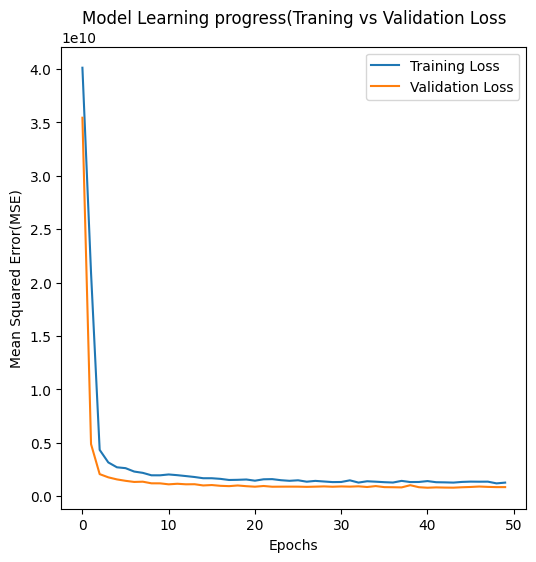

In [31]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.title("Model Learning progress(Traning vs Validation Loss")
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error(MSE)')
plt.legend()




In [7]:
import pandas as pd
# predictions
y_pred=model.predict(X_test_scaled)
# create comparison table
comparison = pd.DataFrame({'Actual': y_test.values,'predicted':y_pred.flatten()})
print(comparison.head())

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
   Actual      predicted
0  192500  186059.515625
1  173000  180668.343750
2  270000  275336.781250
3  127500  130962.617188
4  185850  209043.609375


In [8]:
model.save('house_price_model.keras')
print("Model saved successfully")

Model saved successfully


In [21]:
import joblib
joblib.dump(scale, 'scaler.save')

['scaler.save']